# Testing with smalled model

In [46]:
import torch, torch.nn as nn, torch.optim as optim
from torchvision import models

# tiny toy values
B, C, H, W = 4, 3, 224, 224   # batch size 4
num_classes = 10              # pretend 10 breeds
device = torch.device("cuda")  # or "cuda" if available

# build model (small toy: resnet18->Linear output num_classes)
model = models.resnet18(weights=None)   # weights=None to keep this very small
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model.to(device)

# fake input batch (random pixels) and fake labels
images = torch.randn(B, C, H, W, device=device)  # torch.randn -> floats
labels = torch.randint(0, num_classes, (B,), device=device)

# loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# forward
outputs = model(images)            # shape [B, num_classes]
print("outputs shape:", outputs.shape)

# compute loss
loss = criterion(outputs, labels)
print("loss (scalar):", loss.item())

# backward + step
optimizer.zero_grad()
loss.backward()
optimizer.step()
print("Performed one optimizer step — parameters updated.")

outputs shape: torch.Size([4, 10])
loss (scalar): 2.513270616531372
Performed one optimizer step — parameters updated.


In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


# Using simple ResNet model

Found 120 breeds across 20580 images.
Epoch 1/5 | Train Loss: 3.8356 | Train Acc: 11.63% | Val Top-1: 20.99% | Val Top-5: 53.00%
Epoch 2/5 | Train Loss: 2.9906 | Train Acc: 24.80% | Val Top-1: 31.39% | Val Top-5: 67.25%
Epoch 3/5 | Train Loss: 2.6433 | Train Acc: 31.81% | Val Top-1: 41.66% | Val Top-5: 78.43%
Epoch 4/5 | Train Loss: 2.4248 | Train Acc: 36.48% | Val Top-1: 49.85% | Val Top-5: 83.67%
Epoch 5/5 | Train Loss: 2.2522 | Train Acc: 40.27% | Val Top-1: 49.63% | Val Top-5: 83.67%


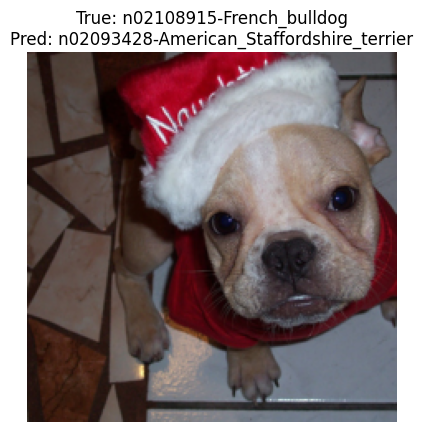

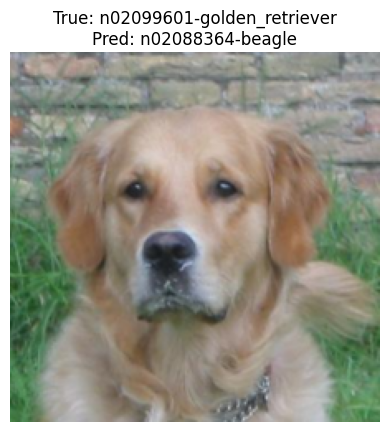

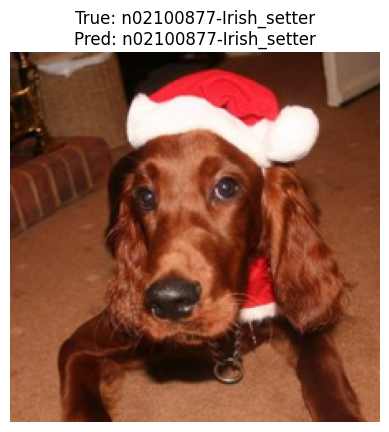

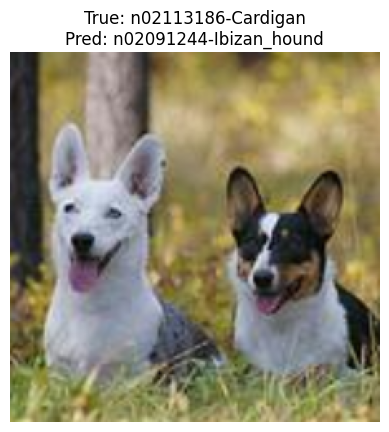

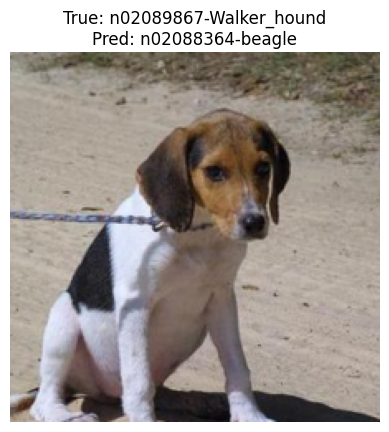

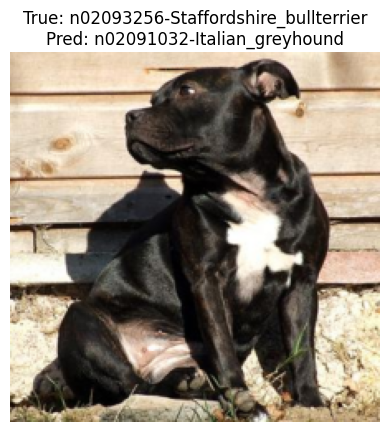

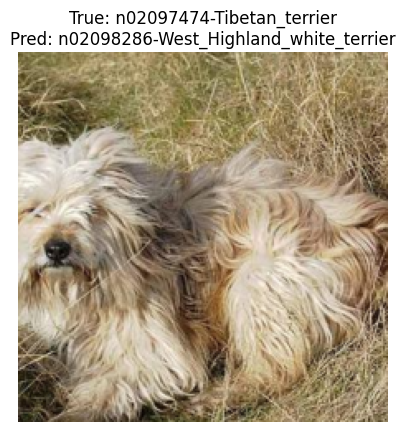

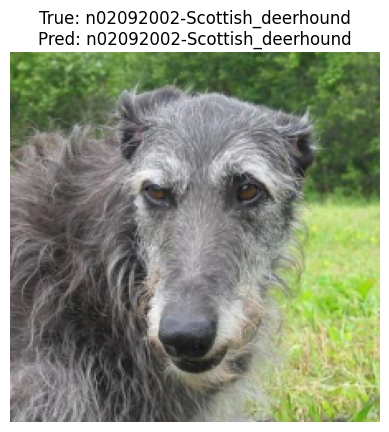

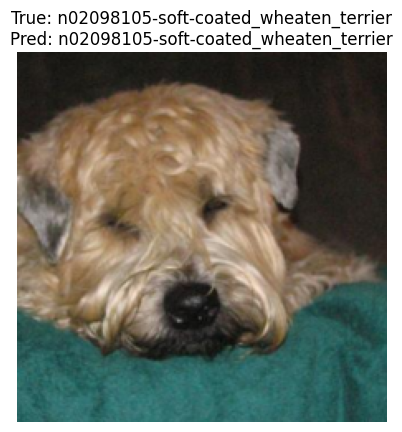

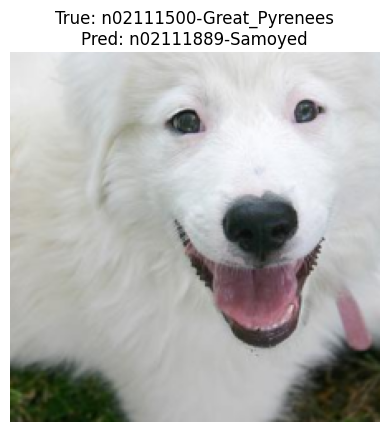

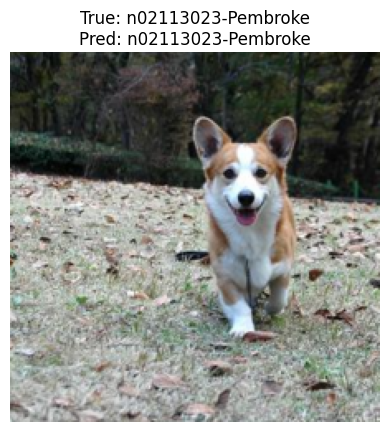

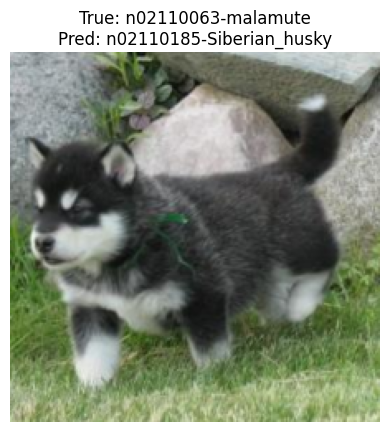

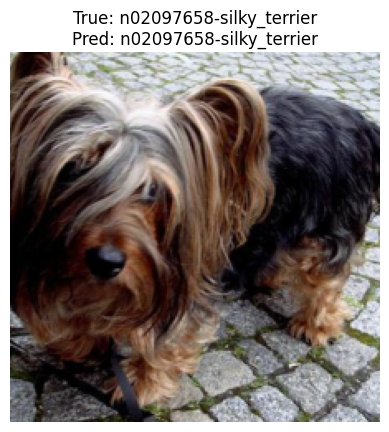

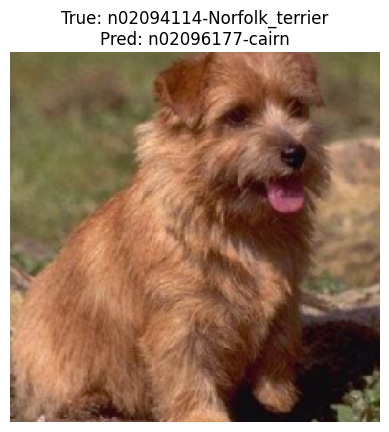

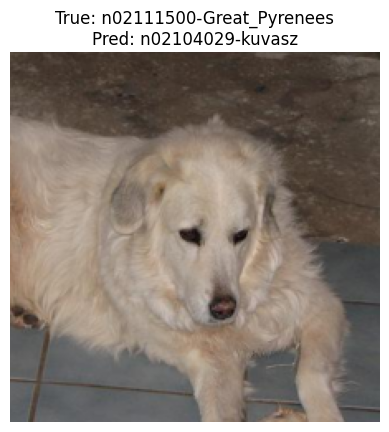

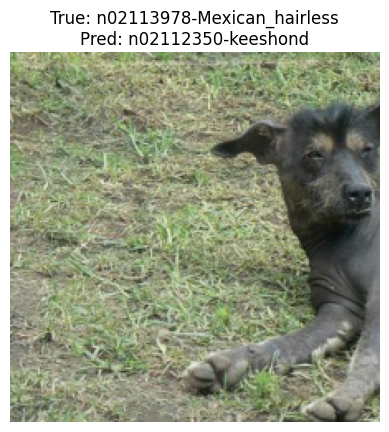

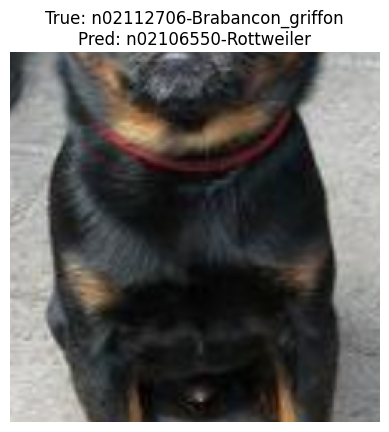

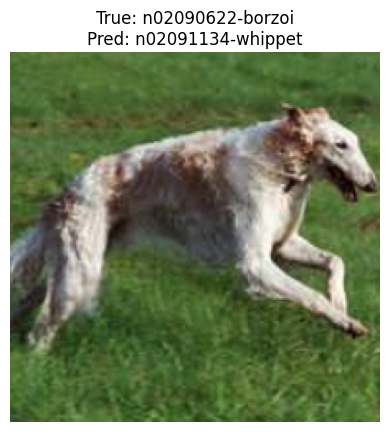

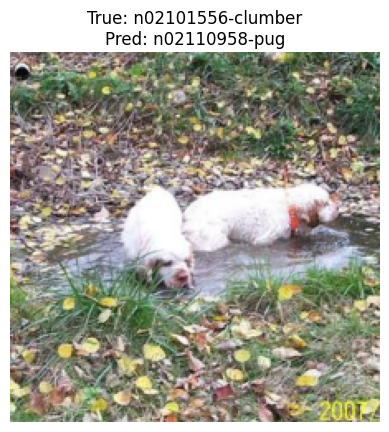

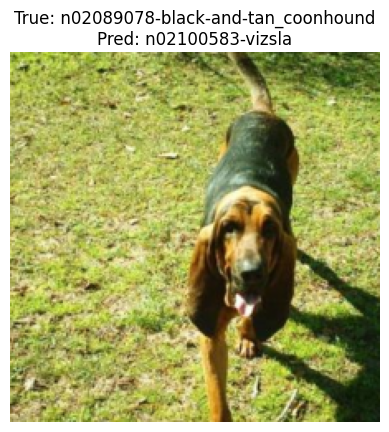

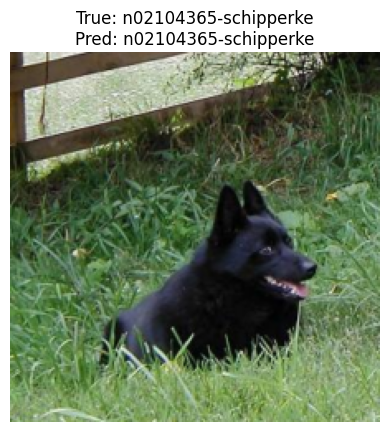

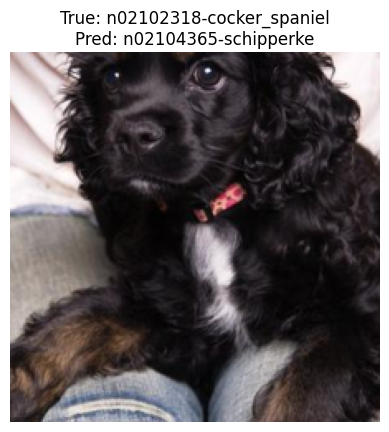

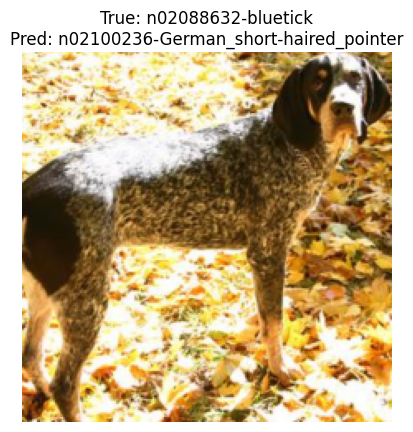

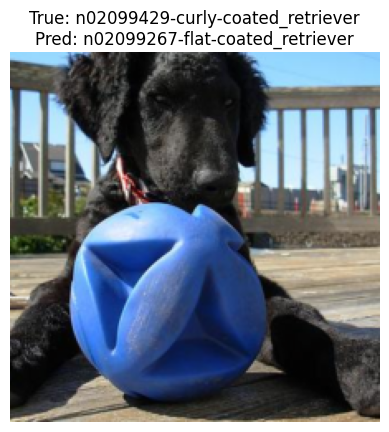

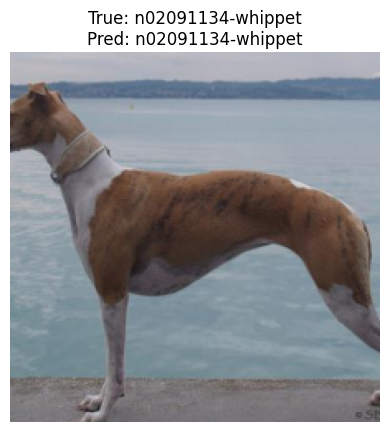

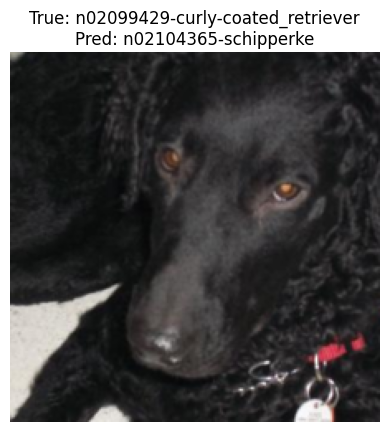

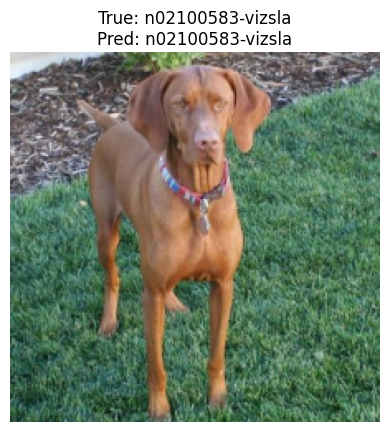

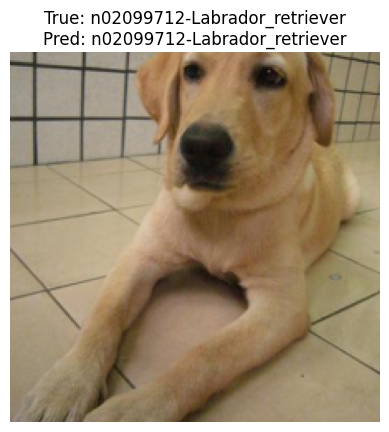

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torchvision.models as models

# -------------------------
# Config: edit these paths/params
# -------------------------
data_dir = "data/Images"   # e.g., "data" or "data/Images" where subfolders are breeds
img_size = 224
batch_size = 32
val_fraction = 0.15
test_fraction = 0.15
epochs = 5
seed = 42
num_workers = os.cpu_count() or 0

# ImageNet normalization (for pretrained models)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# -------------------------
# Transforms (train vs eval)
# -------------------------
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(img_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# -------------------------
# Model (ResNet18 pretrained on ImageNet-1K)
# -------------------------
def create_model(num_classes: int) -> nn.Module:
    try:
        weights = models.ResNet18_Weights.IMAGENET1K_V1
        model = models.resnet18(weights=weights)
    except AttributeError:
        # Fallback for older torchvision
        model = models.resnet18(pretrained=True)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

# -------------------------
# Train for one epoch
# -------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / max(1, len(loader))
    acc = 100.0 * correct / max(1, total)
    return avg_loss, acc

# -------------------------
# Evaluate (val or test)
# -------------------------
@torch.no_grad()
def evaluate(model, loader, device, compute_top5=True):
    model.eval()
    correct_top1, correct_top5, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)                # [B, C]
        preds_top1 = outputs.argmax(dim=1)     # [B]
        correct_top1 += (preds_top1 == labels).sum().item()

        if compute_top5:
            k = min(5, outputs.size(1))
            topk = torch.topk(outputs, k=k, dim=1).indices  # [B, k]
            # Count if true label is in top-k predictions
            correct_top5 += (topk == labels.view(-1, 1)).any(dim=1).sum().item()

        total += labels.size(0)

    top1_acc = 100.0 * correct_top1 / max(1, total)
    top5_acc = 100.0 * correct_top5 / max(1, total) if compute_top5 else None
    return top1_acc, top5_acc

@torch.no_grad()
def evaluate_and_show(model, loader, device, class_names, compute_top5=True):
    model.eval()  # set to evaluation mode
    correct_top1, correct_top5, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)  # Shape [B, num_classes]

        # Get Top-1 predictions (most likely class)
        preds_top1 = outputs.argmax(dim=1)  # Shape [B]
        correct_top1 += (preds_top1 == labels).sum().item()

        # Get Top-5 predictions (5 most likely classes)
        if compute_top5:
            k = min(5, outputs.size(1))  # Top-5
            topk = torch.topk(outputs, k=k, dim=1).indices  # Shape [B, 5]
            correct_top5 += (topk == labels.view(-1, 1)).any(dim=1).sum().item()

        total += labels.size(0)

        # Displaying images and predictions
        for i in range(len(images)):
            # Convert the image tensor back to a format matplotlib understands (from [C, H, W] to [H, W, C])
            img = images[i].cpu().numpy().transpose((1, 2, 0))  # Shape [H, W, C]
            img = img * torch.tensor([0.229, 0.224, 0.225]).cpu().numpy() + torch.tensor([0.485, 0.456, 0.406]).cpu().numpy()  # unnormalize
            
            # Clip the values for better display
            img = img.clip(0, 1)

            # Show the image
            plt.imshow(img)
            plt.axis('off')

            # Get the predicted label and actual label
            pred_class = class_names[preds_top1[i]]
            true_class = class_names[labels[i]]

            # Display prediction vs ground truth
            plt.title(f"True: {true_class}\nPred: {pred_class}")
            plt.show()

    top1_acc = 100.0 * correct_top1 / max(1, total)
    top5_acc = 100.0 * correct_top5 / max(1, total) if compute_top5 else None
    
    return top1_acc, top5_acc

# -------------------------
# Main
# -------------------------
def main():
    torch.manual_seed(seed)

    # Build datasets
    # Two copies: one with train transforms, one with eval transforms.
    ds_train_like = datasets.ImageFolder(root=data_dir, transform=train_transform)
    ds_eval_like  = datasets.ImageFolder(root=data_dir, transform=eval_transform)
    class_names = ds_eval_like.classes
    num_classes = len(class_names)
    print(f"Found {num_classes} breeds across {len(ds_eval_like)} images.")

    # Split lengths
    total_len = len(ds_eval_like)
    test_len  = int(total_len * test_fraction)
    val_len   = int(total_len * val_fraction)
    train_len = total_len - val_len - test_len

    # Split both datasets with the same seed so indices align
    g = torch.Generator().manual_seed(seed)
    train_ds_eval_like, val_ds_eval_like, test_ds_eval_like = random_split(
        ds_eval_like, [train_len, val_len, test_len], generator=g
    )
    g2 = torch.Generator().manual_seed(seed)
    train_ds_train_like, _, _ = random_split(
        ds_train_like, [train_len, val_len, test_len], generator=g2
    )

    # DataLoaders
    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(train_ds_train_like, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
    val_loader   = DataLoader(val_ds_eval_like,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    test_loader  = DataLoader(test_ds_eval_like,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)

    # Model, loss, optimizer
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = create_model(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Train + validate
    best_val = 0.0
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_top1, val_top5 = evaluate(model, val_loader, device)

        print(f"Epoch {epoch}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Top-1: {val_top1:.2f}% | Val Top-5: {val_top5:.2f}%")

        # (Optional) save best checkpoint by Val Top-1
        if val_top1 > best_val:
            best_val = val_top1
            torch.save(model.state_dict(), "best_model.pt")

    # Load best and test
    if os.path.exists("best_model.pt"):
        model.load_state_dict(torch.load("best_model.pt", map_location=device))

    test_top1, test_top5 = evaluate(model, test_loader, device)
    print(f"TEST — Top-1: {test_top1:.2f}% | Top-5: {test_top5:.2f}%")

if __name__ == "__main__":
    main()

# Using more advanced ResNet models with fine tuning, data augmentation, and early stopping

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt


# -------------------------
# Config: edit these paths/params
# -------------------------
data_dir = "data/Images"   # e.g., "data" or "data/Images" where subfolders are breeds
img_size = 224
batch_size = 32
val_fraction = 0.15
test_fraction = 0.15
epochs = 10
seed = 42
num_workers = os.cpu_count() or 0

# ImageNet normalization (for pretrained models)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# -------------------------------------------
# Data Augmentation and Normalization
# -------------------------------------------
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(img_size),    # Randomly crop and resize the image
    transforms.RandomHorizontalFlip(),    # Flip the image horizontally
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Color jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),  # ImageNet normalization
])

eval_transform = transforms.Compose([
    transforms.Resize(256),               # Resize the image to 256x256
    transforms.CenterCrop(img_size),           # Crop to 224x224 (for ResNet)
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# -------------------------------------------
# Model Setup (with Fine-Tuning)
# -------------------------------------------
def create_model(num_classes):
    # Load a pretrained ResNet50 model
    weights = models.ResNet101_Weights.DEFAULT
    model = models.resnet101(weights=weights)
    
    # Freeze the layers except the final fully connected layer
    for param in model.parameters():
        param.requires_grad = False
    
    # Unfreeze the final fully connected layer
    for param in model.fc.parameters():
        param.requires_grad = True
    
    # Replace the final layer for the dog breed classification
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# -------------------------------------------
# Training Loop with Early Stopping
# -------------------------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / max(1, len(loader))
    acc = 100.0 * correct / max(1, total)
    return avg_loss, acc

@torch.no_grad()
def evaluate(model, loader, device, compute_top5=True):
    model.eval()
    correct_top1, correct_top5, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds_top1 = outputs.argmax(dim=1)
        correct_top1 += (preds_top1 == labels).sum().item()

        if compute_top5:
            k = min(5, outputs.size(1))
            topk = torch.topk(outputs, k=k, dim=1).indices
            correct_top5 += (topk == labels.view(-1, 1)).any(dim=1).sum().item()

        total += labels.size(0)

    top1_acc = 100.0 * correct_top1 / max(1, total)
    top5_acc = 100.0 * correct_top5 / max(1, total) if compute_top5 else None
    return top1_acc, top5_acc

def train_model(model, train_loader, val_loader, device, num_epochs=20, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)  # Lower learning rate for fine-tuning

    # Early stopping logic
    best_val_acc = 0
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

        # Evaluate on validation set
        val_top1, val_top5 = evaluate(model, val_loader, device)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Top-1: {val_top1:.2f}% | Val Top-5: {val_top5:.2f}%")

        # Early stopping logic
        if val_top1 > best_val_acc:
            torch.save(model.state_dict(), "best_model_resnet101.pt")
            best_val_acc = val_top1
            epochs_without_improvement = 0
            print(f'Validation accuracy improved. Saving new checkpoint: best_model_resnet101.pt')
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping after {epoch+1} epochs.")
            break
        # torch.cuda.empty_cache()

# -------------------------------------------
# Main Method
# -------------------------------------------
def main():
    torch.manual_seed(seed)

    # Build datasets
    # Two copies: one with train transforms, one with eval transforms.
    ds_train_like = datasets.ImageFolder(root=data_dir, transform=train_transform)
    ds_eval_like  = datasets.ImageFolder(root=data_dir, transform=eval_transform)
    class_names = ds_eval_like.classes
    num_classes = len(class_names)
    print(f"Found {num_classes} breeds across {len(ds_eval_like)} images.")

    # Split lengths
    total_len = len(ds_eval_like)
    test_len  = int(total_len * test_fraction)
    val_len   = int(total_len * val_fraction)
    train_len = total_len - val_len - test_len

    # Split both datasets with the same seed so indices align
    g = torch.Generator().manual_seed(seed)
    train_ds_eval_like, val_ds_eval_like, test_ds_eval_like = random_split(
        ds_eval_like, [train_len, val_len, test_len], generator=g
    )
    g2 = torch.Generator().manual_seed(seed)
    train_ds_train_like, _, _ = random_split(
        ds_train_like, [train_len, val_len, test_len], generator=g2
    )

    # DataLoaders
    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(train_ds_train_like, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
    val_loader   = DataLoader(val_ds_eval_like,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    test_loader  = DataLoader(test_ds_eval_like,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = create_model(num_classes)
    model.to(device)

    # Train the model
    train_model(model, train_loader, val_loader, device, epochs)

    # Evaluate a specific image (testing code)
    test_top1, test_top5 = evaluate(model, test_loader, device)
    print(f"TEST — Top-1: {test_top1:.2f}% | Top-5: {test_top5:.2f}%")
    torch.save(model.state_dict(), "best_model_resnet101.pt")

if __name__ == "__main__":
    main()

Found 120 breeds across 20580 images.


0.7%

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to C:\Users\ekans/.cache\torch\hub\checkpoints\resnet101-cd907fc2.pth


100.0%


Epoch 1/20 | Train Loss: 4.2515 | Train Acc: 24.21% | Val Top-1: 61.97% | Val Top-5: 92.97%
Epoch 2/20 | Train Loss: 3.3747 | Train Acc: 55.05% | Val Top-1: 80.05% | Val Top-5: 97.86%
Epoch 3/20 | Train Loss: 2.7530 | Train Acc: 64.16% | Val Top-1: 84.65% | Val Top-5: 98.61%
Epoch 4/20 | Train Loss: 2.3048 | Train Acc: 67.65% | Val Top-1: 87.04% | Val Top-5: 98.96%
Epoch 5/20 | Train Loss: 1.9827 | Train Acc: 69.78% | Val Top-1: 87.24% | Val Top-5: 98.80%
Epoch 6/20 | Train Loss: 1.7536 | Train Acc: 70.91% | Val Top-1: 88.99% | Val Top-5: 99.00%
Epoch 7/20 | Train Loss: 1.5694 | Train Acc: 72.12% | Val Top-1: 89.28% | Val Top-5: 98.80%
Epoch 8/20 | Train Loss: 1.4357 | Train Acc: 73.02% | Val Top-1: 89.67% | Val Top-5: 99.09%
Epoch 9/20 | Train Loss: 1.3315 | Train Acc: 73.66% | Val Top-1: 89.80% | Val Top-5: 99.13%
Epoch 10/20 | Train Loss: 1.2531 | Train Acc: 74.46% | Val Top-1: 89.93% | Val Top-5: 99.00%
Epoch 11/20 | Train Loss: 1.2034 | Train Acc: 74.30% | Val Top-1: 90.48% | Val 

RuntimeError: cuDNN error: CUDNN_STATUS_BAD_PARAM_STREAM_MISMATCH

: 

# Creating a custom CNN for classification

## Attempt 1

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample  # to match dimensions when channels change

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # If dimensions don’t match, project with 1x1 conv
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [7]:
class MiniResNet(nn.Module):
    def __init__(self, num_classes):
        super(MiniResNet, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers
        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride, downsample))
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

Found 120 classes across 20580 images.
Epoch 1/30 | Train Loss: 4.6351, Train Acc: 0.0270 | Val Loss: 4.5580, Val Acc: 0.0321
Epoch 2/30 | Train Loss: 4.2654, Train Acc: 0.0534 | Val Loss: 4.3159, Val Acc: 0.0549
Epoch 3/30 | Train Loss: 4.0397, Train Acc: 0.0768 | Val Loss: 4.1598, Val Acc: 0.0525
Epoch 4/30 | Train Loss: 3.8395, Train Acc: 0.1049 | Val Loss: 4.0135, Val Acc: 0.0928
Epoch 5/30 | Train Loss: 3.6506, Train Acc: 0.1305 | Val Loss: 3.6261, Val Acc: 0.1463
Epoch 6/30 | Train Loss: 3.4640, Train Acc: 0.1611 | Val Loss: 3.5949, Val Acc: 0.1482
Epoch 7/30 | Train Loss: 3.2518, Train Acc: 0.1970 | Val Loss: 4.1590, Val Acc: 0.1278
Epoch 8/30 | Train Loss: 3.0545, Train Acc: 0.2291 | Val Loss: 3.5505, Val Acc: 0.1919
Epoch 9/30 | Train Loss: 2.8632, Train Acc: 0.2694 | Val Loss: 3.0956, Val Acc: 0.2498
Epoch 10/30 | Train Loss: 2.6620, Train Acc: 0.3089 | Val Loss: 3.2008, Val Acc: 0.2366
Epoch 11/30 | Train Loss: 2.1863, Train Acc: 0.4229 | Val Loss: 2.6850, Val Acc: 0.3197
Ep

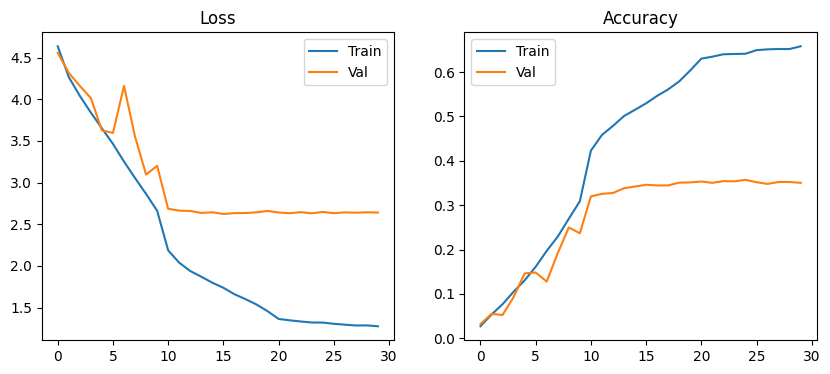

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ----------------------------
# Stronger CNN with nn.Sequential
# ----------------------------
def create_model(num_classes):
    model = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(256, 512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),

        nn.Linear(512 * 8 * 8, 1024),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(1024, 512),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(512, num_classes)
    )
    return model


# ----------------------------
# Training & Evaluation
# ----------------------------
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)

    return total_loss / total, correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)

    return total_loss / total, correct / total


# ----------------------------
# Main Training Script
# ----------------------------
def main():
    # Params
    data_dir = "./data/Images"   # Your dataset root (all images under class folders here)
    batch_size = 64
    num_workers = 4
    lr = 1e-3
    epochs = 30
    test_fraction = 0.1
    val_fraction = 0.1
    seed = 42

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Data augmentation
    train_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # ----------------------------
    # Dataset loading with random splits (your method)
    # ----------------------------
    ds_train_like = datasets.ImageFolder(root=data_dir, transform=train_transform)
    ds_eval_like  = datasets.ImageFolder(root=data_dir, transform=eval_transform)
    class_names = ds_eval_like.classes
    num_classes = len(class_names)
    print(f"Found {num_classes} classes across {len(ds_eval_like)} images.")

    total_len = len(ds_eval_like)
    test_len  = int(total_len * test_fraction)
    val_len   = int(total_len * val_fraction)
    train_len = total_len - val_len - test_len

    g = torch.Generator().manual_seed(seed)
    train_ds_eval_like, val_ds_eval_like, test_ds_eval_like = random_split(
        ds_eval_like, [train_len, val_len, test_len], generator=g
    )
    g2 = torch.Generator().manual_seed(seed)
    train_ds_train_like, _, _ = random_split(
        ds_train_like, [train_len, val_len, test_len], generator=g2
    )

    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(train_ds_train_like, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
    val_loader   = DataLoader(val_ds_eval_like,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    test_loader  = DataLoader(test_ds_eval_like,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)

    # ----------------------------
    # Model, Loss, Optimizer
    # ----------------------------
    # model = create_model(num_classes).to(device) # Using the custom CNN
    model = MiniResNet(num_classes=num_classes).to(device) # Emulating ResNet
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    # ----------------------------
    # Training Loop
    # ----------------------------
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # ----------------------------
    # Final Test
    # ----------------------------
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"\nTest Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    # ----------------------------
    # Plot Learning Curves
    # ----------------------------
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train")
    plt.plot(val_accs, label="Val")
    plt.title("Accuracy")
    plt.legend()
    plt.show()


if __name__ == "__main__":
    main()

## Attempt 2

This has been the best so far giving me around 50% validation accuracy

Found 120 classes across 20580 images.
Epoch 1/60 | LR: 0.000999 | Train Loss: 4.8061, Train Acc: 0.0169 | Val Loss: 4.9670, Val Acc: 0.0209
Validation accuracy improved → checkpoint saved: best_model.pth
Epoch 2/60 | LR: 0.000997 | Train Loss: 4.6762, Train Acc: 0.0226 | Val Loss: 4.5201, Val Acc: 0.0369
Validation accuracy improved → checkpoint saved: best_model.pth
Epoch 3/60 | LR: 0.000994 | Train Loss: 4.6187, Train Acc: 0.0263 | Val Loss: 4.6011, Val Acc: 0.0326
EarlyStopping counter: 1/10
Epoch 4/60 | LR: 0.000989 | Train Loss: 4.5553, Train Acc: 0.0353 | Val Loss: 5.0034, Val Acc: 0.0248
EarlyStopping counter: 2/10
Epoch 5/60 | LR: 0.000983 | Train Loss: 4.5038, Train Acc: 0.0380 | Val Loss: 4.4159, Val Acc: 0.0462
Validation accuracy improved → checkpoint saved: best_model.pth
Epoch 6/60 | LR: 0.000976 | Train Loss: 4.4558, Train Acc: 0.0451 | Val Loss: 4.2669, Val Acc: 0.0617
Validation accuracy improved → checkpoint saved: best_model.pth
Epoch 7/60 | LR: 0.000967 | Train Los

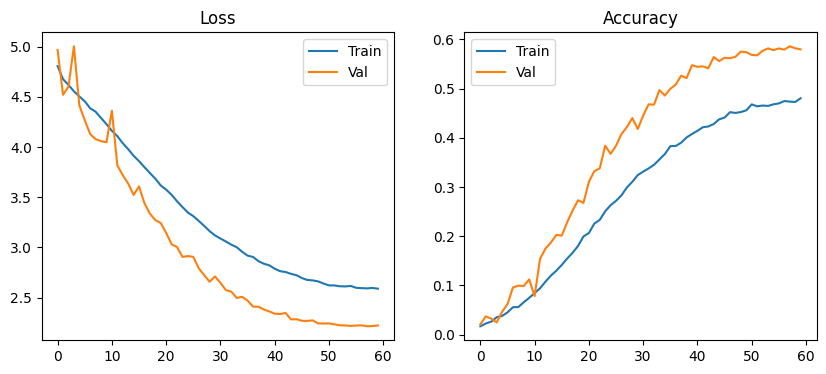

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ----------------------------
# Residual Block
# ----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, dropout_prob=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)  # Dropout between convs
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)

# ----------------------------
# Mini ResNet-like Model
# ----------------------------
class MiniResNet(nn.Module):
    def __init__(self, num_classes, dropout_prob=0.5):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        # More stacked blocks (deeper network)
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128, stride=2,
                downsample=nn.Sequential(
                    nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False),
                    nn.BatchNorm2d(128))),
            ResidualBlock(128, 128),
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(128, 256, stride=2,
                downsample=nn.Sequential(
                    nn.Conv2d(128, 256, kernel_size=1, stride=2, bias=False),
                    nn.BatchNorm2d(256))),
            ResidualBlock(256, 256),
        )
        self.layer5 = nn.Sequential(
            ResidualBlock(256, 512, stride=2,
                downsample=nn.Sequential(
                    nn.Conv2d(256, 512, kernel_size=1, stride=2, bias=False),
                    nn.BatchNorm2d(512))),
            ResidualBlock(512, 512),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Dropout(p=dropout_prob),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# ----------------------------
# Early Stopping (same as before)
# ----------------------------
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path="best_model.pth"):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_acc_max = 0

    def __call__(self, val_acc, model):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
            self.counter = 0

    def save_checkpoint(self, val_acc, model):
        torch.save(model.state_dict(), self.path)
        self.val_acc_max = val_acc
        if self.verbose:
            print(f"Validation accuracy improved → checkpoint saved: {self.path}")

# ----------------------------
# Training & Evaluation
# ----------------------------
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)
    return total_loss / total, correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)
    return total_loss / total, correct / total

# ----------------------------
# Main Training Script
# ----------------------------
def main():
    # Params
    data_dir = "./data/Images"
    batch_size = 64
    num_workers = 4
    lr = 1e-3
    epochs = 60
    test_fraction = 0.1
    val_fraction = 0.1
    seed = 42

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Stronger Data Augmentation
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    eval_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Dataset loading
    ds_train_like = datasets.ImageFolder(root=data_dir, transform=train_transform)
    ds_eval_like  = datasets.ImageFolder(root=data_dir, transform=eval_transform)
    class_names = ds_eval_like.classes
    num_classes = len(class_names)
    print(f"Found {num_classes} classes across {len(ds_eval_like)} images.")

    total_len = len(ds_eval_like)
    test_len  = int(total_len * test_fraction)
    val_len   = int(total_len * val_fraction)
    train_len = total_len - val_len - test_len

    g = torch.Generator().manual_seed(seed)
    train_ds_eval_like, val_ds_eval_like, test_ds_eval_like = random_split(
        ds_eval_like, [train_len, val_len, test_len], generator=g
    )
    g2 = torch.Generator().manual_seed(seed)
    train_ds_train_like, _, _ = random_split(
        ds_train_like, [train_len, val_len, test_len], generator=g2
    )

    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(train_ds_train_like, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
    val_loader   = DataLoader(val_ds_eval_like,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    test_loader  = DataLoader(test_ds_eval_like,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)

    # Model, Loss, Optimizer
    model = MiniResNet(num_classes=num_classes).to(device)

    # Label smoothing
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # Cosine Annealing Scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    early_stopping = EarlyStopping(patience=10, verbose=True, path="best_model.pth")

    # Training Loop
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"LR: {current_lr:.6f} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        early_stopping(val_acc, model)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    # Restore best model
    model.load_state_dict(torch.load("best_model.pth"))
    print(f"Restored best model with Val Acc={early_stopping.val_acc_max:.4f}")

    # Final Test
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"\nTest Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    # Plot Learning Curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.title("Loss")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train")
    plt.plot(val_accs, label="Val")
    plt.title("Accuracy")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

## Attempt 3

Found 120 classes across 20580 images.
Epoch 1/60 | LR: 0.000999 | Train Loss: 4.8982, Train Acc: 0.0111 | Val Loss: 4.8670, Val Acc: 0.0151
Validation accuracy improved → checkpoint saved: best_model.pth
Epoch 2/60 | LR: 0.000997 | Train Loss: 4.7364, Train Acc: 0.0179 | Val Loss: 4.6486, Val Acc: 0.0209
Validation accuracy improved → checkpoint saved: best_model.pth
Epoch 3/60 | LR: 0.000994 | Train Loss: 4.7014, Train Acc: 0.0195 | Val Loss: 4.5921, Val Acc: 0.0224
Validation accuracy improved → checkpoint saved: best_model.pth
Epoch 4/60 | LR: 0.000989 | Train Loss: 4.6738, Train Acc: 0.0236 | Val Loss: 4.5623, Val Acc: 0.0321
Validation accuracy improved → checkpoint saved: best_model.pth
Epoch 5/60 | LR: 0.000983 | Train Loss: 4.6468, Train Acc: 0.0256 | Val Loss: 4.6249, Val Acc: 0.0292
EarlyStopping counter: 1/10
Epoch 6/60 | LR: 0.000976 | Train Loss: 4.5988, Train Acc: 0.0326 | Val Loss: 4.4675, Val Acc: 0.0462
Validation accuracy improved → checkpoint saved: best_model.pth
E

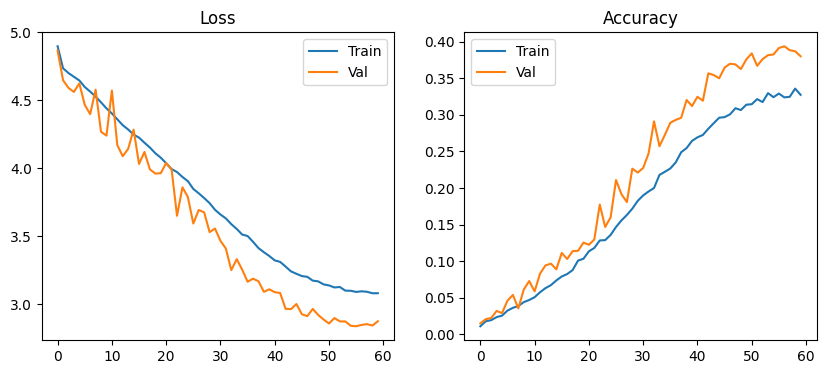

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ----------------------------
# Residual Block
# ----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, dropout_prob=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)  # Dropout between convs
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)

# ----------------------------
# Bottleneck Block (ResNet-50/101 style)
# ----------------------------
class BottleneckBlock(nn.Module):
    expansion = 4  # output channels are multiplied

    def __init__(self, in_channels, out_channels, stride=1, downsample=None, dropout_prob=0.3):
        super().__init__()
        width = out_channels

        self.conv1 = nn.Conv2d(in_channels, width, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(width)
        self.conv2 = nn.Conv2d(width, width, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(width)
        self.conv3 = nn.Conv2d(width, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=dropout_prob)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.dropout(out)
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        return self.relu(out)

# ----------------------------
# Custom ResNet (with Bottleneck)
# ----------------------------
class CustomResNet(nn.Module):
    def __init__(self, num_classes, dropout_prob=0.5):
        super().__init__()
        self.in_channels = 64

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.layer2 = self._make_layer(BottleneckBlock, 64, 3, stride=1, dropout_prob=dropout_prob)
        self.layer3 = self._make_layer(BottleneckBlock, 128, 4, stride=2, dropout_prob=dropout_prob)
        self.layer4 = self._make_layer(BottleneckBlock, 256, 6, stride=2, dropout_prob=dropout_prob)
        self.layer5 = self._make_layer(BottleneckBlock, 512, 3, stride=2, dropout_prob=dropout_prob)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Dropout(p=dropout_prob),
            nn.Linear(512 * BottleneckBlock.expansion, num_classes)
        )

    def _make_layer(self, block, out_channels, blocks, stride=1, dropout_prob=0.3):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample, dropout_prob))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels, dropout_prob=dropout_prob))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)
    
# ----------------------------
# Mini ResNet-like Model
# ----------------------------
class MiniResNet(nn.Module):
    def __init__(self, num_classes, dropout_prob=0.5):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        # More stacked blocks (deeper network)
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128, stride=2,
                downsample=nn.Sequential(
                    nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False),
                    nn.BatchNorm2d(128))),
            ResidualBlock(128, 128),
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(128, 256, stride=2,
                downsample=nn.Sequential(
                    nn.Conv2d(128, 256, kernel_size=1, stride=2, bias=False),
                    nn.BatchNorm2d(256))),
            ResidualBlock(256, 256),
        )
        self.layer5 = nn.Sequential(
            ResidualBlock(256, 512, stride=2,
                downsample=nn.Sequential(
                    nn.Conv2d(256, 512, kernel_size=1, stride=2, bias=False),
                    nn.BatchNorm2d(512))),
            ResidualBlock(512, 512),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Dropout(p=dropout_prob),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# ----------------------------
# Early Stopping (same as before)
# ----------------------------
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path="best_model.pth"):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_acc_max = 0

    def __call__(self, val_acc, model):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
            self.counter = 0

    def save_checkpoint(self, val_acc, model):
        torch.save(model.state_dict(), self.path)
        self.val_acc_max = val_acc
        if self.verbose:
            print(f"Validation accuracy improved → checkpoint saved: {self.path}")

# ----------------------------
# Training & Evaluation
# ----------------------------
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)
    return total_loss / total, correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)
    return total_loss / total, correct / total

# ----------------------------
# Main Training Script
# ----------------------------
def main():
    # Params
    data_dir = "./data/Images"
    batch_size = 64
    num_workers = 4
    lr = 1e-3
    epochs = 60
    test_fraction = 0.1
    val_fraction = 0.1
    seed = 42

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Stronger Data Augmentation
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    eval_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Dataset loading
    ds_train_like = datasets.ImageFolder(root=data_dir, transform=train_transform)
    ds_eval_like  = datasets.ImageFolder(root=data_dir, transform=eval_transform)
    class_names = ds_eval_like.classes
    num_classes = len(class_names)
    print(f"Found {num_classes} classes across {len(ds_eval_like)} images.")

    total_len = len(ds_eval_like)
    test_len  = int(total_len * test_fraction)
    val_len   = int(total_len * val_fraction)
    train_len = total_len - val_len - test_len

    g = torch.Generator().manual_seed(seed)
    train_ds_eval_like, val_ds_eval_like, test_ds_eval_like = random_split(
        ds_eval_like, [train_len, val_len, test_len], generator=g
    )
    g2 = torch.Generator().manual_seed(seed)
    train_ds_train_like, _, _ = random_split(
        ds_train_like, [train_len, val_len, test_len], generator=g2
    )

    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(train_ds_train_like, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
    val_loader   = DataLoader(val_ds_eval_like,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    test_loader  = DataLoader(test_ds_eval_like,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)

    # Model, Loss, Optimizer
    # model = MiniResNet(num_classes=num_classes).to(device)
    model = CustomResNet(num_classes=num_classes).to(device)

    # Label smoothing
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # Cosine Annealing Scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    early_stopping = EarlyStopping(patience=10, verbose=True, path="best_model.pth")

    # Training Loop
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"LR: {current_lr:.6f} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        early_stopping(val_acc, model)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    # Restore best model
    model.load_state_dict(torch.load("best_model.pth"))
    print(f"Restored best model with Val Acc={early_stopping.val_acc_max:.4f}")

    # Final Test
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"\nTest Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    # Plot Learning Curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.title("Loss")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train")
    plt.plot(val_accs, label="Val")
    plt.title("Accuracy")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

## Attempt 4

* More residual blocks (closer to ResNet-34 depth).
* RandAugment() for stronger augmentation.
* Mixup augmentation applied in train_one_epoch.
* CosineAnnealingWarmRestarts scheduler.
* Epochs bumped to 100 (with early stopping, it won’t overtrain).

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.transforms import RandAugment
import matplotlib.pyplot as plt
import random

# ----------------------------
# Residual Block
# ----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, dropout_prob=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)

# ----------------------------
# Deeper Mini ResNet-like Model
# ----------------------------
class MiniResNet(nn.Module):
    def __init__(self, num_classes, dropout_prob=0.5):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        # closer to ResNet-34: multiple blocks per stage
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
            ResidualBlock(64, 64),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128, stride=2,
                downsample=nn.Sequential(
                    nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False),
                    nn.BatchNorm2d(128))),
            ResidualBlock(128, 128),
            ResidualBlock(128, 128),
            ResidualBlock(128, 128),
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(128, 256, stride=2,
                downsample=nn.Sequential(
                    nn.Conv2d(128, 256, kernel_size=1, stride=2, bias=False),
                    nn.BatchNorm2d(256))),
            ResidualBlock(256, 256),
            ResidualBlock(256, 256),
            ResidualBlock(256, 256),
            ResidualBlock(256, 256),
            ResidualBlock(256, 256),
        )
        self.layer5 = nn.Sequential(
            ResidualBlock(256, 512, stride=2,
                downsample=nn.Sequential(
                    nn.Conv2d(256, 512, kernel_size=1, stride=2, bias=False),
                    nn.BatchNorm2d(512))),
            ResidualBlock(512, 512),
            ResidualBlock(512, 512),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Dropout(p=dropout_prob),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# ----------------------------
# Early Stopping
# ----------------------------
class EarlyStopping:
    def __init__(self, patience=10, verbose=False, delta=0, path="best_model.pth"):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_acc_max = 0

    def __call__(self, val_acc, model):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
            self.counter = 0

    def save_checkpoint(self, val_acc, model):
        torch.save(model.state_dict(), self.path)
        self.val_acc_max = val_acc
        if self.verbose:
            print(f"Validation accuracy improved → checkpoint saved: {self.path}")

# ----------------------------
# Mixup function
# ----------------------------
def mixup_data(x, y, alpha=0.4):
    if alpha > 0:
        lam = random.betavariate(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ----------------------------
# Training & Evaluation
# ----------------------------
def train_one_epoch(model, dataloader, criterion, optimizer, device, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        if use_mixup:
            inputs, targets_a, targets_b, lam = mixup_data(inputs, targets)
            outputs = model(inputs)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            _, predicted = outputs.max(1)
            correct += (lam * predicted.eq(targets_a).sum().item()
                        + (1 - lam) * predicted.eq(targets_b).sum().item())
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        total += targets.size(0)
    return total_loss / total, correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)
    return total_loss / total, correct / total

# ----------------------------
# Main Training Script
# ----------------------------
def main():
    data_dir = "./data/Images"
    batch_size = 64
    num_workers = 4
    lr = 1e-3
    epochs = 100
    test_fraction = 0.1
    val_fraction = 0.1
    seed = 42

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Stronger Data Augmentation with RandAugment
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        RandAugment(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    eval_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Dataset loading
    ds_train_like = datasets.ImageFolder(root=data_dir, transform=train_transform)
    ds_eval_like  = datasets.ImageFolder(root=data_dir, transform=eval_transform)
    class_names = ds_eval_like.classes
    num_classes = len(class_names)
    print(f"Found {num_classes} classes across {len(ds_eval_like)} images.")

    total_len = len(ds_eval_like)
    test_len  = int(total_len * test_fraction)
    val_len   = int(total_len * val_fraction)
    train_len = total_len - val_len - test_len

    g = torch.Generator().manual_seed(seed)
    train_ds_eval_like, val_ds_eval_like, test_ds_eval_like = random_split(
        ds_eval_like, [train_len, val_len, test_len], generator=g
    )
    g2 = torch.Generator().manual_seed(seed)
    train_ds_train_like, _, _ = random_split(
        ds_train_like, [train_len, val_len, test_len], generator=g2
    )

    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(train_ds_train_like, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
    val_loader   = DataLoader(val_ds_eval_like,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    test_loader  = DataLoader(test_ds_eval_like,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)

    # Model, Loss, Optimizer
    model = MiniResNet(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # Scheduler: Cosine Annealing with Warm Restarts
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    early_stopping = EarlyStopping(patience=15, verbose=True, path="best_model.pth")

    # Training Loop
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, use_mixup=True)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        scheduler.step(epoch + val_loss)  # warm restart step

        current_lr = optimizer.param_groups[0]["lr"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"LR: {current_lr:.6f} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        early_stopping(val_acc, model)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    # Restore best model
    model.load_state_dict(torch.load("best_model.pth"))
    print(f"Restored best model with Val Acc={early_stopping.val_acc_max:.4f}")

    # Final Test
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"\nTest Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    # Plot Learning Curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.title("Loss")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train")
    plt.plot(val_accs, label="Val")
    plt.title("Accuracy")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()

Found 120 classes across 20580 images.
Epoch 1/100 | LR: 0.000540 | Train Loss: 4.8565, Train Acc: 0.0112 | Val Loss: 4.7454, Val Acc: 0.0199
Validation accuracy improved → checkpoint saved: best_model.pth
Epoch 2/100 | LR: 0.000395 | Train Loss: 4.7508, Train Acc: 0.0161 | Val Loss: 4.6739, Val Acc: 0.0287
Validation accuracy improved → checkpoint saved: best_model.pth


RuntimeError: cuDNN error: CUDNN_STATUS_BAD_PARAM_STREAM_MISMATCH

# Testing models with inputted images

In [4]:
def file_path_fixer(path):
    path = path.replace('dog_classifier\\', '')
    path = path.replace('\\','/')
    return path

def clean_name(name):
    return name.split('-')[1]

In [7]:
eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
])

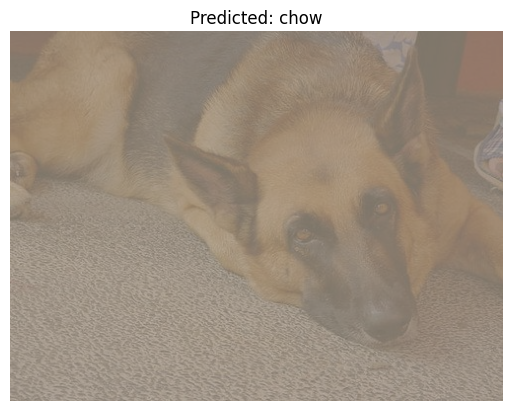

Top-1 Prediction: chow
Top-5 Predictions:
1. chow: 1.2671
2. Brabancon_griffon: 1.2037
3. Airedale: 0.4587
4. Pomeranian: 0.0032
5. Norfolk_terrier: -0.1721
Model's Prediction: chow


In [13]:
import torch
from torchvision import transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt
import os

def evaluate_on_single_image(model, image_path, device, class_names, topk=5):
    # Step 1: Load the image
    img = Image.open(image_path).convert("RGB")  # Open image and ensure it is RGB (3 channels)

    # Step 2: Define the necessary transformations
    transform = transforms.Compose([
        transforms.Resize(256),  # Resize the image to 256x256
        transforms.CenterCrop(224),  # Crop to 224x224 (for ResNet)
        transforms.ToTensor(),  # Convert to tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize like ImageNet
    ])

    # Apply transformations
    img_tensor = transform(img).unsqueeze(0).to(device)  # Add batch dimension and move to device

    # Step 3: Run the image through the model
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():  # Disable gradient calculation
        outputs = model(img_tensor)  # Forward pass

        # Get Top-1 prediction (index of the max logit)
        _, preds = torch.max(outputs, 1)

        # Get Top-5 predictions using torch.topk
        probs, topk_preds = torch.topk(outputs, topk, dim=1)

    # Step 4: Denormalize the image to show it correctly
    img = img.convert("RGB")  # Convert the image back to RGB if it's in a different format
    img = transforms.functional.to_tensor(img).cpu().numpy().transpose((1, 2, 0))  # Convert to NumPy and HWC format
    # Denormalize the image for display
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # Denormalize the image for display
    img = img.clip(0, 1)  # Clip values to range [0, 1]

    # Step 5: Display the image and prediction
    plt.imshow(img)
    plt.axis('off')  # Turn off axis
    pred_class = class_names[preds.item()]  # Convert the predicted index to class name
    plt.title(f"Predicted: {clean_name(pred_class)}")
    plt.show()

    # Step 6: Display Top-5 Predictions
    print(f"Top-1 Prediction: {clean_name(pred_class)}")
    print("Top-5 Predictions:")
    for i in range(topk):
        class_name = class_names[topk_preds[0][i].item()]  # Get class name for the index
        prob = probs[0][i].item()  # Get the probability of the prediction
        print(f"{i + 1}. {clean_name(class_name)}: {prob:.4f}")

    # Print out the prediction (you can also return it if needed)
    print(f"Model's Prediction: {clean_name(pred_class)}")

# Initialize the class names
data_dir = './data/Images'
ds_eval_like  = datasets.ImageFolder(root=data_dir, transform=eval_transform)
class_names = ds_eval_like.classes
num_classes = len(class_names)

image_path = file_path_fixer(r'dog_classifier\data\Images\n02106662-German_shepherd\n02106662_24110.jpg')  # Example image path from the dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize and load best model
# model = create_model(num_classes).to(device)
model = MiniResNet(num_classes=num_classes).to(device)
if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth", map_location=device))

# Make sure to pass your trained model and class names
evaluate_on_single_image(model, image_path, device, class_names)